In [1]:
import os
import sys

# Change to project root
os.chdir('c:/Users/PC_ATIC_01/cats-dogs-classifier')

# ADD SRC TO PYTHON PATH 
sys.path.insert(0, 'src')

# Verify
print("Current directory:", os.getcwd())
print("Python path:", sys.path[:3])
print("Files in current directory:", os.listdir())

Current directory: c:\Users\PC_ATIC_01\cats-dogs-classifier
Python path: ['src', 'C:\\Users\\PC_ATIC_01\\AppData\\Local\\Python\\pythoncore-3.14-64\\python314.zip', 'C:\\Users\\PC_ATIC_01\\AppData\\Local\\Python\\pythoncore-3.14-64\\DLLs']
Files in current directory: ['%USERPROFILE%.kaggle', '%USERPROFILE%.kaggleaccess_token', '.git', '.gitignore', '.vscode', 'data', 'dogs-vs-cats-redux-kernels-edition.zip', 'models', 'requirements.txt', 'sample_submission.csv', 'src', 'test.zip', 'train.zip', 'venv']


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from torchvision import transforms
import matplotlib.pyplot as plt
import os
from custom_model import CustomCNN

In [4]:
# ============ HYPERPARAMETERS ============
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.7
VAL_SPLIT = 0.2  # 20% for validation

In [5]:
# ============ MODEL ARCHITECTURE ============
NUM_CONV_LAYERS = 3
CONV_CHANNELS = [32, 64, 128]  # Output channels for each conv layer
KERNEL_SIZES = [3, 3, 3]  # Kernel size for each conv layer
POOL_TYPE = 'avg'  # 'max' or 'avg'
NUM_HIDDEN_LAYERS = 2
HIDDEN_SIZES = [256, 128]  # Size of each hidden layer
ACTIVATION = 'relu'  # 'relu', 'elu', 'leaky_relu'

In [6]:
# ============ SETUP ============
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Data preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Load data
print("Loading data...")
full_dataset = ImageFolder('data/train', transform=transform)
print(f"Total images: {len(full_dataset)}")

# Split into train/validation
train_size = int((1 - VAL_SPLIT) * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Classes: {full_dataset.classes}")

# Create model
print("\nCreating model...")
model = CustomCNN(
    num_conv_layers=NUM_CONV_LAYERS,
    conv_channels=CONV_CHANNELS,
    kernel_sizes=KERNEL_SIZES,
    pool_type=POOL_TYPE,
    dropout_rate=DROPOUT_RATE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    hidden_sizes=HIDDEN_SIZES,
    activation=ACTIVATION
)
model = model.to(device)

print(f"Model Architecture:\n{model}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

Using device: cpu
Loading data...
Total images: 1312
Training samples: 1049
Validation samples: 263
Classes: ['cats', 'dogs']

Creating model...
Model Architecture:
CustomCNN(
  (activation): ReLU()
  (conv_layers): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (dropout): Dropout(p=0.7, inplace=Fal

In [7]:
# ============ TRAINING ============
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("\n" + "="*60)
print("Starting training...")
print("="*60)

for epoch in range(EPOCHS):
    # ===== Training =====
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_acc = 100 * train_correct / train_total
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)
    
    # ===== Validation =====
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)
    
    # Print progress
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"  Train - Loss: {avg_train_loss:.4f}, Acc: {train_acc:.2f}%")
    print(f"  Val   - Loss: {avg_val_loss:.4f}, Acc: {val_acc:.2f}%")
    
    # Check for overfitting
    if val_acc < train_acc - 10:
        print(f"  ⚠️ WARNING: Possible overfitting! (gap: {train_acc - val_acc:.2f}%)")
    print()


Starting training...
Epoch [1/20]
  Train - Loss: 2.3078, Acc: 79.12%
  Val   - Loss: 1.1709, Acc: 87.07%

Epoch [2/20]
  Train - Loss: 1.7876, Acc: 82.75%
  Val   - Loss: 0.7794, Acc: 87.45%

Epoch [3/20]
  Train - Loss: 1.3091, Acc: 79.60%
  Val   - Loss: 0.6474, Acc: 87.45%

Epoch [4/20]
  Train - Loss: 1.2515, Acc: 79.89%
  Val   - Loss: 0.3971, Acc: 87.45%

Epoch [5/20]
  Train - Loss: 0.7949, Acc: 81.89%
  Val   - Loss: 0.3855, Acc: 87.45%

Epoch [6/20]
  Train - Loss: 0.6272, Acc: 83.32%
  Val   - Loss: 0.4134, Acc: 87.45%

Epoch [7/20]
  Train - Loss: 0.5098, Acc: 84.08%
  Val   - Loss: 0.3984, Acc: 87.45%

Epoch [8/20]
  Train - Loss: 0.4316, Acc: 87.04%
  Val   - Loss: 0.4318, Acc: 87.45%

Epoch [9/20]
  Train - Loss: 0.4356, Acc: 85.99%
  Val   - Loss: 0.4184, Acc: 87.45%

Epoch [10/20]
  Train - Loss: 0.3955, Acc: 86.84%
  Val   - Loss: 0.4143, Acc: 87.45%

Epoch [11/20]
  Train - Loss: 0.3941, Acc: 88.08%
  Val   - Loss: 0.3972, Acc: 87.45%

Epoch [12/20]
  Train - Loss: 

Model saved to models/custom_cnn_model.pth
Results saved to models/training_results.png


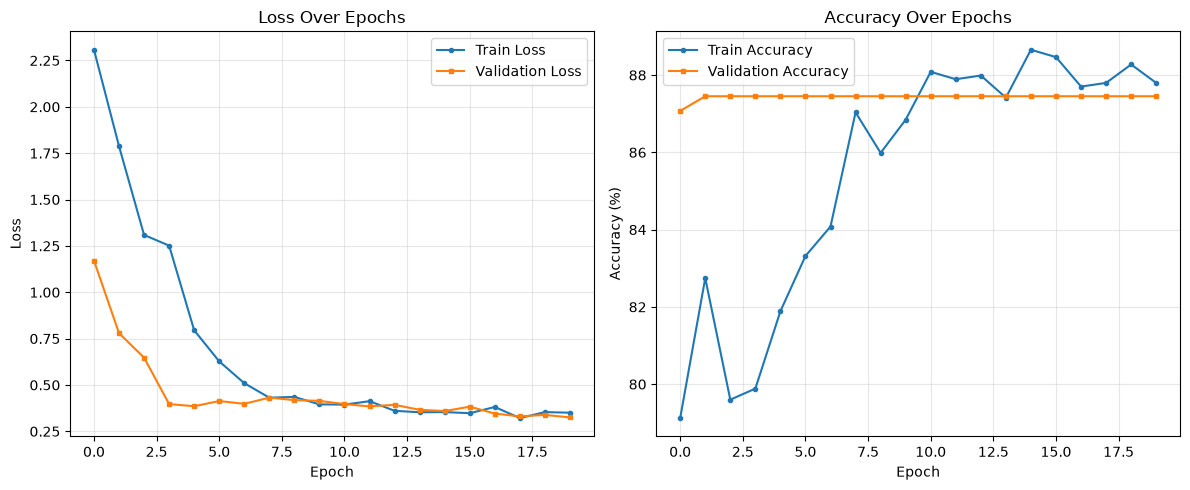

In [8]:
# ============ SAVE MODEL ============
os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/custom_cnn_model.pth')
print("Model saved to models/custom_cnn_model.pth")

# ============ PLOT RESULTS ============
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o', markersize=3)
plt.plot(val_losses, label='Validation Loss', marker='s', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy', marker='o', markersize=3)
plt.plot(val_accs, label='Validation Accuracy', marker='s', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/training_resultsv4.png', dpi=100)
print("Results saved to models/training_results.png")
plt.show()

In [9]:
# ============ DETECT OVERFITTING ============
print("\n" + "="*60)
print("OVERFITTING ANALYSIS")
print("="*60)

final_train_acc = train_accs[-1]
final_val_acc = val_accs[-1]
gap = final_train_acc - final_val_acc

print(f"Final Training Accuracy: {final_train_acc:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc:.2f}%")
print(f"Accuracy Gap: {gap:.2f}%")

if gap < 5:
    print("✓ Good! Minimal overfitting")
elif gap < 15:
    print("⚠️ Moderate overfitting - consider increasing dropout")
else:
    print("❌ Severe overfitting - try: more dropout, more regularization, or simpler model")


OVERFITTING ANALYSIS
Final Training Accuracy: 87.80%
Final Validation Accuracy: 87.45%
Accuracy Gap: 0.35%
✓ Good! Minimal overfitting


Confusion Matrix:
[[230   0]
 [ 33   0]]


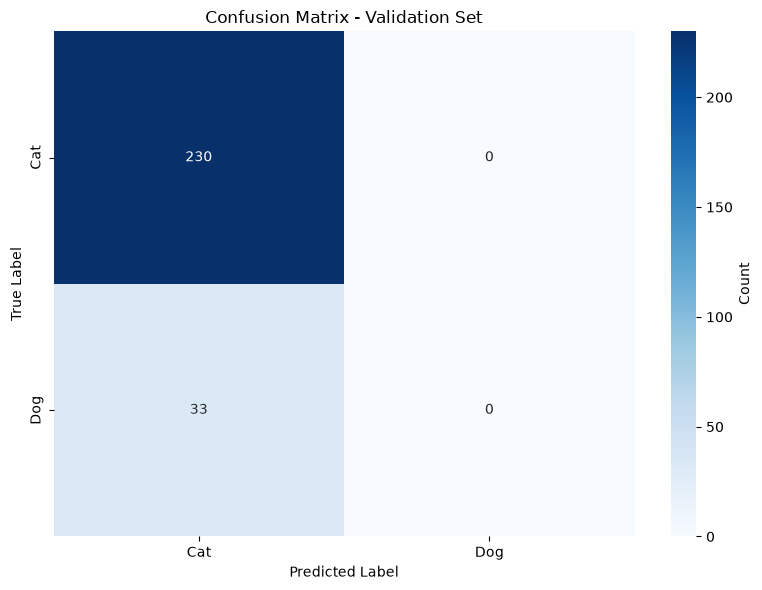


CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Cat       0.87      1.00      0.93       230
         Dog       0.00      0.00      0.00        33

    accuracy                           0.87       263
   macro avg       0.44      0.50      0.47       263
weighted avg       0.76      0.87      0.82       263



c:\Users\PC_ATIC_01\cats-dogs-classifier\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC_ATIC_01\cats-dogs-classifier\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC_ATIC_01\cats-dogs-classifier\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# ============ GENERATE CONFUSION MATRIX ============
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

# ============ VISUALIZE CONFUSION MATRIX ============
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'],
            cbar_kws={'label': 'Count'})
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Validation Set')
plt.tight_layout()
plt.savefig('models/confusion_matrixv4.png', dpi=100)
plt.show()

# ============ DETAILED METRICS ============
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_labels, all_preds, 
                          target_names=['Cat', 'Dog']))